In [12]:
import sys
import numpy as np
import pandas as pd
import sklearn

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Sklearn:", sklearn.__version__)

Python: 3.10.12 (main, Jan 26 2026, 14:55:28) [GCC 11.4.0]
NumPy: 2.2.6
Pandas: 2.3.3
Sklearn: 1.7.2


In [1]:
import numpy as np

np.random.seed(42)

X = np.random.randn(100, 5) 
print("Размер матрицы X:", X.shape)

print(f'Среднее значение: {X.mean():.4f}')
print(f'Отклонение: {X.std():.4f}')
print(f'Минимум: {X.min():.4f}')
print(f'Максимум: {X.max():.4f}')

print("Среднее по столбцам:", X.mean(axis=0))
print("Среднее по строкам:", X.mean(axis=1))

#Задание 4.1
w = np.random.randn(5)

y= X @ w
print(f'w= {w}')
print(f'Размер y: {y.shape}')
print('Первые 5 строк:', y[:5])

#4.2


# 1. Задаем "идеальные" веса. 
# Это то, сколько на самом деле стоит каждый признак в нашем мире.
w_true = np.array([1.5, -2.0, 0.0, 0.7, 3.0 ])
# 2. Создаем "шум" (случайные помехи).
noise = 0.1 * np.random.randn(X.shape[0])

# 3. Считаем "истинную" цену (ПРАВДА).
y_true = X @ w_true + noise


# 4. Наши "догадки" о весах.
w_guess = w_true + 0.5 * np.random.randn(5)
# 5. Считаем наши предсказания.
y_pred = X @ w_guess

# 6. MSE (Средний Квадрат Ошибки)
mse = np.mean((y_true-y_pred)**2)
# 7. MAE (Средняя Ошибка "в лоб")
mae = np.mean(np.abs(y_true-y_pred))
# 8. RMSE (возвращаем отклонение,ранее возведенное в квадрат)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)


# 9. Сумма квадратов остатков (наш косяк)
ss_res = np.sum((y_true-y_pred) ** 2)
# 10. Общая сумма квадратов отклонений у рельных значений
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
# 11. Коэффициент R2 
r2 = 1 - ss_res/ss_tot

print("R2:", r2)



Размер матрицы X: (100, 5)
Среднее значение: 0.0068
Отклонение: 0.9803
Минимум: -3.2413
Максимум: 3.8527
Среднее по столбцам: [-0.04474719  0.07695423 -0.09387351  0.12805847 -0.03220203]
Среднее по строкам: [ 0.45900297  0.43711925 -0.86507665 -0.71623982 -0.13234605 -0.31134108
  0.20038167 -0.820595   -0.19708782 -0.30855652  0.1809511   0.21793176
 -0.4309698   0.40085582  0.16170094 -0.25717318  0.05771418  0.14518068
 -0.07122017 -0.22716262 -0.62845871  0.52958381  0.07716525  0.19858268
  0.09388897  0.04595946 -0.59804719  0.0054545   0.07432722 -0.19133164
  0.0884485   0.21810123  0.22273846  0.42650196 -0.23291673  0.94984631
 -0.20867462 -0.24944635 -0.08971605 -0.28591531  0.33555116  0.89175507
  0.59931598 -0.1308328  -0.19019883  0.00795598  0.20480151 -0.20282448
 -0.14736222  0.14153203  0.2584459   0.25869222 -1.10093579 -0.27096343
  0.03945986 -0.05091304  0.65137654 -0.37145267 -0.01677407  0.39129615
 -0.01048275  0.22966512  0.76510009  0.11734267  0.19206044  

In [2]:
#Задание 5.1

import pandas as pd
#создаем названия колонок
col_names = [f"x:{i}" for i in range(X.shape[1])]

#создаем таблицу
df = pd.DataFrame(X, columns = col_names)
#добавляем новый столбей
df['target'] = y_true

#проверка работы
display(df.head())
print("Shape:", df.shape)
display(df.describe())
print('\nMissing values:\n', df.isnull().sum())


#Задание 5.2 (фильтрация)

top_negative_x2 = df[df['x:2'] < 0].sort_values('target', ascending = False).head(10)
print('\n\nФильтрация:')
display(top_negative_x2)


#Задание 5.3 (создание битов)
#разрезание на 3 части
df['x:0_category'] = pd.cut(df['x:0'], bins= 3, labels =['Low', 'Middle', 'High'] )
#пишет к-во строк в каждом бите
print(df['x:0_category'].value_counts())

#создаем группы по x:0_category (нас интересуют только значения target)
grouped = df.groupby('x:0_category', observed= True)['target'].mean()
display(grouped)




,x:0,x:1,x:2,x:3,x:4,target
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,1.336548
1,-0.234137,1.579213,0.767435,-0.469474,0.542560,-2.269822
2,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-6.364116
3,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,-3.685445
4,1.465649,-0.225776,0.067528,-1.424748,-0.544383,-0.063541


Shape: (100, 6)


,x:0,x:1,x:2,x:3,x:4,target
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,-0.044747,0.076954,-0.093874,0.128058,-0.032202,-0.238401
std,0.900352,0.984110,0.983943,0.959556,1.072806,3.940301
min,-1.952088,-2.301921,-3.241267,-1.913280,-2.619745,-9.222826
25%,-0.734897,-0.678136,-0.700307,-0.536288,-0.757046,-3.315029
50%,-0.010110,0.066421,-0.024662,0.152465,-0.145714,-1.036352
75%,0.524237,0.830645,0.532419,0.667929,0.648170,2.600386
max,2.314659,1.886186,2.122156,3.078881,3.852731,10.120710



Missing values:
 x:0       0
x:1       0
x:2       0
x:3       0
x:4       0
target    0
dtype: int64


Фильтрация:


,x:0,x:1,x:2,x:3,x:4,target
94,-0.275052,-2.301921,-1.515191,1.366874,1.644968,10.120710
86,-1.183259,-2.039232,-0.269407,0.717542,1.502357,7.265162
11,0.931280,-0.839218,-0.309212,0.331263,0.975545,6.283967
82,0.711615,-1.124642,-1.534114,1.277677,0.332314,5.123038
10,0.324084,-0.385082,-0.676922,0.611676,1.031000,4.853002
29,0.781823,-1.236951,-1.320457,0.521942,0.296985,4.837765
81,0.622850,-1.067620,-0.142379,0.120296,0.514439,4.651103
25,2.190456,-0.990536,-0.566298,0.099651,-0.503476,3.889944
23,0.301547,-0.034712,-1.168678,1.142823,0.751933,3.603492
97,-1.422254,-0.646573,-1.081548,1.687142,0.881640,3.072644


x:0_category
Middle    58
Low       31
High      11
Name: count, dtype: int64


x:0_category
Low      -1.714124
Middle    0.069918
High      2.294774
Name: target, dtype: float64

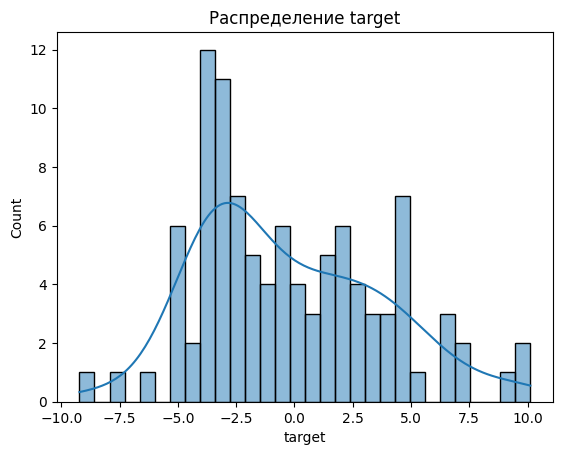

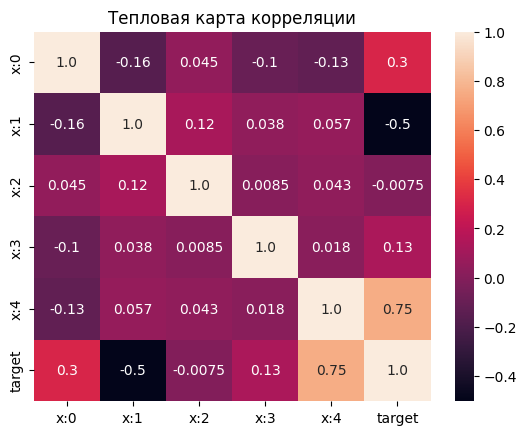

In [3]:
#Задание 6.1

import matplotlib.pyplot as plt
import seaborn as sns

#Создаем раму для картинки
plt.figure()
#Создаем гистограмму
sns.histplot(df['target'], bins = 30, kde = True)
#Название гистограммы
plt.title('Распределение target')
#Показат гистограмму
plt.show


#Задание 6.2
#Создаем корееляцию
corr = df.corr(numeric_only= True)

#Создаем опять раму для графика
plt.figure()
#Создаем тепловую карту
sns.heatmap(corr, annot= True, fmt='.2')
plt.title('Тепловая карта корреляции')
plt.show()



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


к-во растений относится к определенному виду:
 target
0    50
1    50
2    50
Name: count, dtype: int64


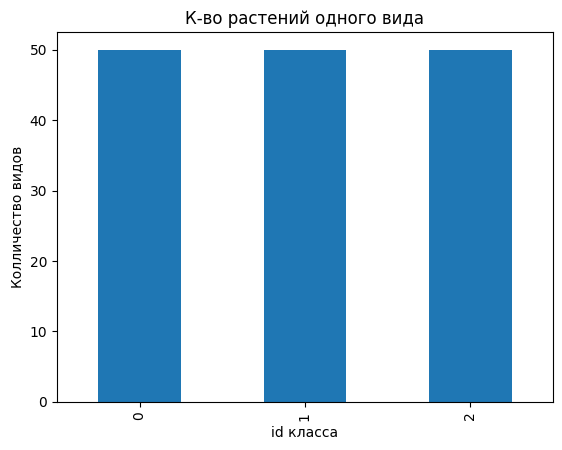

In [4]:
#Задание 7.1
#Пример с цветами

#Импортирует нам тестовый датабейс
from sklearn.datasets import load_iris
#для разрезания датабейса на часть для учебы и часть для проверки(экзамена)
from sklearn.model_selection import train_test_split
#импорт алгоритма (регрессии в данном случае)
from sklearn.linear_model import LogisticRegression
#для проверки результатов работы нейросетки
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


iris = load_iris(as_frame= True)
display(iris.frame.head())
#создаем копию iris
iris_copy = iris.frame.copy()

#Какое к-во растений относится к определенному виду
print(f"к-во растений относится к определенному виду:\n {iris['target'].value_counts()}")

#рисуем красивый график для target
plt.figure()
iris['target'].value_counts().sort_index().plot(kind = 'bar')
plt.title('К-во растений одного вида')
plt.xlabel('id класса')
plt.ylabel('Колличество видов')
plt.show()


In [5]:
#Задание 7.2 (Обучение робота)
#Все данные кроме нашей колонки
test_iris = iris_copy.drop(columns = ['target'])
#Только эта колонка(ответы)
true_iris = iris['target']

#Материалы для обучения и теста
X_train, X_test, answers_train, answers_test = train_test_split(
    test_iris, true_iris, test_size=0.2, random_state=42, stratify=true_iris)

#Обучение робота 
model = LogisticRegression(max_iter=1000) # Создаем робота
model.fit(X_train, answers_train)         # Даем ему материалы и ответы ; запуск обучения

#проверка работы робота
y_pred = model.predict(X_test)

#Выводим результаты 
print('Точность ответов: ', accuracy_score(answers_test, y_pred))
print('Матрица ошибок: \n', confusion_matrix(answers_test, y_pred))
print('Классификация ошибок: \n', classification_report(answers_test, y_pred))






Точность ответов:  0.9666666666666667
Матрица ошибок: 
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Классификация ошибок: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

